In [1]:
import pandas as pd
import re
from pathlib import Path
import numpy as np
import os
from sklearn import metrics
from sklearn.metrics import confusion_matrix, precision_recall_curve, precision_score, recall_score, f1_score, roc_auc_score, PrecisionRecallDisplay
from sklearn.metrics import ConfusionMatrixDisplay, auc
import matplotlib.pyplot as plt
import soundfile as sf
from intervaltree import IntervalTree
# from utils.metadata_processing import (reorder_columns_to_default_view, 
                                       # correct_call_times_with_duration,
                                       # non_overlap_df, bg_from_non_overlap_calls)

In [55]:
# annotations_folder = r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\verified_annotations'
wav_folder = r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\wavs'
annotations_folder = r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\augmented_annotations2'
# augmented_annotation_folder = r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\augmented_annotations'
predictions_folder = r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\placencia_inference_mft3'
annotation_dfs = []
prediction_dfs = []

def extract_recording_filename_from_annotation(filename):
    return filename.split('adjusted_')[1].split('.Table.1.selections_bb.txt')[0]
    # filename = filename.split('adjusted_')[1]
    # return filename.split('.Table.1.selections_bb.txt')[0]

def extract_recording_filename_from_prediction(filename):
    
    # return filename.split('-o5ot9qky-')[1].split('.csv')[0] #no finetune
    return filename.split('-kvfeyzgr-')[1].split('.csv')[0] #3%
    # return filename.split('-andy4xav-')[1].split('.csv')[0] #5%
    # return filename.split('-vmtz5rix-')[1].split('.csv')[0] #10%
    # return filename.split('-cygu8w4d-')[1].split('.csv')[0] #15%


# Read all annotation files
name_mappings = []
for annotation_file in os.listdir(annotations_folder):
    if annotation_file.endswith('.txt'):
        file_path = os.path.join(annotations_folder, annotation_file)
        # augmented_file_path = os.path.join(augmented_annotation_folder, annotation_file.split('adjusted_')[1])
        df = pd.read_csv(file_path, delimiter='\t')
        # df_augmented = pd.read_csv(augmented_file_path, delimiter='\t')
        # df.loc[:, 'SNR'] = df_augmented.loc[:, 'SNR']
        # df.loc[:, 'NUM HARM'] = df_augmented.loc[:, 'NUM HARM']
        # df['NUM HARM']=df['NUM HARM'].str.replace('[^0-9]', '', regex=True).astype(np.int64)
        recording_filename = extract_recording_filename_from_annotation(annotation_file)
        name_mappings.append([recording_filename, annotation_file])
        df['recording_filename'] = recording_filename
        annotation_dfs.append(df)

# Read all prediction files
for prediction_file in os.listdir(predictions_folder):
    if prediction_file.endswith('.csv'):
        file_path = os.path.join(predictions_folder, prediction_file)
        df = pd.read_csv(file_path)
        recording_filename = extract_recording_filename_from_prediction(prediction_file)
        df['recording_filename'] = recording_filename
        # Add a column for time_segment in the predictions dataframe
        df['time_segment'] = df.index * 0.2
        prediction_dfs.append(df)

# Concatenate all dataframes into a single dataframe for annotations and predictions
annotations_df = pd.concat(annotation_dfs, ignore_index=True)
predictions_df = pd.concat(prediction_dfs, ignore_index=True)   
annotations_df.to_csv("placencia_annotations_5files.csv")
annotations_df  = annotations_df[annotations_df['Begin Time (s)'] <= 10800]
# Create a DataFrame
mapper_to_correct_times = pd.DataFrame(name_mappings, columns=['File Name', 'Raven Table file name'])


In [7]:
predictions_df

,channel,0,1,recording_filename,time_segment
0,1,0.949899,0.050101,67670025.201212101523,0.0
1,1,0.369054,0.630946,67670025.201212101523,0.2
2,1,0.008088,0.991912,67670025.201212101523,0.4
3,1,0.000302,0.999698,67670025.201212101523,0.6
4,1,0.000031,0.999969,67670025.201212101523,0.8
...,...,...,...,...,...
269893,1,0.994476,0.005524,67670025.201212221503,10798.0
269894,1,0.996694,0.003306,67670025.201212221503,10798.2
269895,1,0.995869,0.004131,67670025.201212221503,10798.4
269896,1,0.998733,0.001267,67670025.201212221503,10798.6


In [5]:
# Fix time offset 
#####ONLY RUN FIRST TIME WE GET NEW ANNOTATIONS###
annotation_files_list = set(annotations_df['recording_filename'].unique())
# wavs lengths
wavs_length_dict = {}
for a in annotation_files_list:
    path_to_wav = f'{wav_folder}/{a+".wav"}'
    wavs_length_dict[a]=sf.info(path_to_wav).frames/sf.info(path_to_wav).samplerate

# maximal end_time per file in the trainset
end_time_max_details = annotations_df.groupby('recording_filename')['End Time (s)'].max().reset_index()[['recording_filename', 'End Time (s)']]
end_time_dict = dict(zip(end_time_max_details['recording_filename'],end_time_max_details['End Time (s)']))

# print details about problematic files
for a in annotation_files_list:
    if wavs_length_dict[a] < end_time_dict[a]:
        print(f'file length: {wavs_length_dict[a]}, last end time: {end_time_dict[a]}')

strt_time = 0
for j, name in enumerate(mapper_to_correct_times['File Name']):
    path_to_wav = f'{wav_folder}/{name}'+".wav"
    print(j)
    if j >0:
        annotations_df.loc[annotations_df['recording_filename']==name, 'Begin Time (s)'] -= strt_time
        annotations_df.loc[annotations_df['recording_filename']==name, 'End Time (s)'] -= strt_time
    time_obj = sf.info(path_to_wav).frames/sf.info(path_to_wav).samplerate
    strt_time += time_obj
    print(strt_time)
    adjusted_file_path = os.path.join(annotations_folder, f'adjusted_{name}.txt')
    # annotations_df[annotations_df['recording_filename'] == name].to_csv(adjusted_file_path, sep='\t', index=False)
    # print(f"Adjusted annotation file {adjusted_file_path} have been saved.")
# Check again after change:
end_time_max_details = annotations_df.groupby('recording_filename')['End Time (s)'].max().reset_index()[['recording_filename', 'End Time (s)']]
end_time_dict = dict(zip(end_time_max_details['recording_filename'],end_time_max_details['End Time (s)']))
for a in annotation_files_list:
    if wavs_length_dict[a] < end_time_dict[a]:
        print(f'file length: {wavs_length_dict[a]}, last end time after change: {end_time_dict[a]}')

0
10787.7335
1
21584.561833333333
2
32382.652166666667
3
43181.0245
4
53980.148166666666


In [8]:
annotations_df#['NUM HARM'].value_counts()

,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),Delta Time (s),Delta Freq (Hz),High Freq (Hz),Inband Power (dB FS),Begin Date Time,SNR,NUM HARM,recording_filename
0,1,Spectrogram 1,1,412.928222,413.186087,11902.439,0.2579,12682.927,24585.366,-93.32,2012/12/10 15:29:52.9282,3.3,2,67670025.201212101523
1,2,Spectrogram 1,1,415.595797,415.688457,3719.600,0.0927,10914.546,14634.146,-93.64,2012/12/10 15:29:55.5958,0.3,2,67670025.201212101523
2,3,Spectrogram 1,1,418.951454,419.321578,9560.976,0.3701,14243.902,23804.878,-92.90,2012/12/10 15:29:58.9515,4.1,3,67670025.201212101523
3,4,Spectrogram 1,1,463.320853,463.487096,1170.732,0.1662,6829.268,8000.000,-94.22,2012/12/10 15:30:43.3209,0.8,2,67670025.201212101523
4,5,Spectrogram 1,1,496.389546,496.454953,7414.634,0.0654,15798.481,23213.115,-94.09,2012/12/10 15:31:16.3895,0.0,1,67670025.201212101523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,669,Spectrogram 1,1,9785.462775,9785.778815,3594.714,0.3160,16704.846,20299.559,NaN,2012/12/11 6:05:46.4873,NaN,4,67670025.201212221503
620,670,Spectrogram 1,1,9787.890885,9788.230049,3806.167,0.3392,14167.401,17973.568,NaN,2012/12/11 6:05:48.9154,NaN,3,67670025.201212221503
621,671,Spectrogram 1,1,9791.744891,9792.037806,6555.066,0.2929,24105.727,30660.793,NaN,2012/12/11 6:05:52.7694,NaN,4,67670025.201212221503
622,672,Spectrogram 1,1,9799.420572,9799.721195,5920.705,0.3006,13744.493,19665.198,NaN,2012/12/11 6:06:00.4451,NaN,2,67670025.201212221503


In [9]:
predictions_df[predictions_df['recording_filename']=="67670025.201212221503"].tail(20)

,channel,0,1,recording_filename,time_segment
269878,1,0.996514,0.003486,67670025.201212221503,10795.0
269879,1,0.998650,0.001350,67670025.201212221503,10795.2
269880,1,0.996501,0.003499,67670025.201212221503,10795.4
269881,1,0.996142,0.003858,67670025.201212221503,10795.6
269882,1,0.995280,0.004720,67670025.201212221503,10795.8
269883,1,0.995701,0.004299,67670025.201212221503,10796.0
269884,1,0.997076,0.002925,67670025.201212221503,10796.2
269885,1,0.993894,0.006106,67670025.201212221503,10796.4
269886,1,0.998081,0.001919,67670025.201212221503,10796.6
269887,1,0.992269,0.007731,67670025.201212221503,10796.8


In [56]:
# Convert begin_time and end_time to seconds
annotations_df['Begin Time (s)'] = annotations_df['Begin Time (s)'].astype(float)
annotations_df['End Time (s)'] = annotations_df['End Time (s)'].astype(float)


# Remove predictions after 5660/48840 seconds in the last recording  # TODO: remove this part if section is annotated
# specific_recording_filename = "67670025.201212221503"
# predictions_df = predictions_df[~((predictions_df['recording_filename'] == specific_recording_filename) & (predictions_df['time_segment'] > 48840))]

# Check predicted probability distribution
print("Predicted probability distribution:")
print(predictions_df['1'].describe())

# Filter out only the positive predictions
# positive_predictions = predictions_df[predictions_df['1'] > 0.5]
all_predictions = predictions_df

# def is_intersecting(segment_start, segment_end, annotations):
#     for _, row in annotations.iterrows():
#         if segment_start <= row['end_time'] and segment_end >= row['begin_time']:
#             return True
#     return False

Predicted probability distribution:
count    269898.000000
mean          0.004195
std           0.026480
min           0.000217
25%           0.002220
50%           0.002900
75%           0.003836
max           1.000000
Name: 1, dtype: float64


In [57]:
true_labels = []
predicted_probs = []
num_harm_labels = []  # To store NUM HARM values corresponding to true labels #TODO: try checking for NUM_HARM>2, and combine non-number values

 # Calculate the number of negative (background) labels
def calculate_metrics_at_threshold(threshold):
    true_labels = []
    predicted_labels = []
    
    # Iterate over each annotation and check for intersections with predictions
    for _, annotation in annotations_df.iterrows():
        annotation_start = annotation['Begin Time (s)']
        annotation_end = annotation['End Time (s)']
        recording_filename = annotation['recording_filename']
        
        # Get the predictions for the current recording
        recording_predictions = predictions_df[predictions_df['recording_filename'] == recording_filename]
        
        # Check for intersections
        intersects = (recording_predictions['time_segment'] < annotation_end) & \
                     ((recording_predictions['time_segment'] + 0.2) > annotation_start)
        
        if intersects.any():
            intersecting_predictions = recording_predictions[intersects]
            if intersecting_predictions['1'].max() >= threshold:
                predicted_labels.append(1)
            else:
                predicted_labels.append(0)
        else:
            predicted_labels.append(0)
        
        true_labels.append(1)
    
    # Calculate the number of negative (background) labels
    negative_labels_count = len(predictions_df) - len(annotations_df)
    true_labels.extend([0] * negative_labels_count)
    
    # For the negative labels, consider the threshold to determine predicted labels
    for i in range(negative_labels_count):
        predicted_labels.append(1 if predictions_df['1'].iloc[len(annotations_df) + i] >= threshold else 0)
    
    # Convert to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    
    # Metrics for call (positive examples)
    call_precision = precision_score(true_labels, predicted_labels, pos_label=1)
    call_recall = recall_score(true_labels, predicted_labels, pos_label=1)
    call_f1 = f1_score(true_labels, predicted_labels, pos_label=1)
    
    # Metrics for background (negative examples)
    background_precision = precision_score(true_labels, predicted_labels, pos_label=0)
    background_recall = recall_score(true_labels, predicted_labels, pos_label=0)
    background_f1 = f1_score(true_labels, predicted_labels, pos_label=0)
    
    # Confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)
    # MCC
    # mcc = matthews_corrcoef(true_labels, predicted_labels)

    # Calculate AUC-ROC
    # auc_roc = roc_auc_score(true_labels, predicted_probs)
    
    # Calculate AUC-PR
    # precisions, recalls, thresholds = precision_recall_curve(true_labels, predicted_probs)
    # auc_pr = auc(recalls, precisions)
    
    return call_precision, call_recall, call_f1, background_precision, background_recall, background_f1, conf_matrix

# Calculate metrics for thresholds 0.9999 and 0.00001
metrics_high_threshold = calculate_metrics_at_threshold(0.5)
metrics_low_threshold = calculate_metrics_at_threshold(0.01)

print(f'\nMetrics at threshold 0.5:')
print(f'Call Precision: {metrics_high_threshold[0]:.4f}')
print(f'Call Recall: {metrics_high_threshold[1]:.4f}')
print(f'Call F1 Score: {metrics_high_threshold[2]:.4f}')
print(f'Background Precision: {metrics_high_threshold[3]:.4f}')
print(f'Background Recall: {metrics_high_threshold[4]:.4f}')
print(f'Background F1 Score: {metrics_high_threshold[5]:.4f}')
print(f'Confusion Matrix:\n{metrics_high_threshold[6]}')

print(f'\nMetrics at threshold 0.01:')
print(f'Call Precision: {metrics_low_threshold[0]:.4f}')
print(f'Call Recall: {metrics_low_threshold[1]:.4f}')
print(f'Call F1 Score: {metrics_low_threshold[2]:.4f}')
print(f'Background Precision: {metrics_low_threshold[3]:.4f}')
print(f'Background Recall: {metrics_low_threshold[4]:.4f}')
print(f'Background F1 Score: {metrics_low_threshold[5]:.4f}')
print(f'Confusion Matrix:\n{metrics_low_threshold[6]}')
# print(f'MCC: {metrics_low_threshold[7]:.4f}')
# print(f'AUC-ROC: {metrics_low_threshold[8]:.4f}')
# print(f'AUC-PR: {metrics_low_threshold[9]:.4f}')
# Calculate precision-recall curve
# precisions, recalls, thresholds = precision_recall_curve(true_labels, predicted_probs)

# Find the best threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]

print(f'\nBest Threshold: {best_threshold:.4f}')


Metrics at threshold 0.5:
Call Precision: 0.4494
Call Recall: 0.2917
Call F1 Score: 0.3537
Background Precision: 0.9984
Background Recall: 0.9992
Background F1 Score: 0.9988
Confusion Matrix:
[[269051    223]
 [   442    182]]

Metrics at threshold 0.01:
Call Precision: 0.1495
Call Recall: 0.6939
Call F1 Score: 0.2460
Background Precision: 0.9993
Background Recall: 0.9909
Background F1 Score: 0.9951
Confusion Matrix:
[[266811   2463]
 [   191    433]]

Best Threshold: 0.0287


In [58]:
def calculate_metrics_at_threshold(threshold):
    true_labels = []
    predicted_labels = []
    predicted_probs = []
    
    # Iterate over each annotation and check for intersections with predictions
    for _, annotation in annotations_df.iterrows():
        annotation_start = annotation['Begin Time (s)']
        annotation_end = annotation['End Time (s)']
        recording_filename = annotation['recording_filename']
        
        # Get the predictions for the current recording
        recording_predictions = predictions_df[predictions_df['recording_filename'] == recording_filename]
        
        # Check for intersections
        intersects = (recording_predictions['time_segment'] < annotation_end) & \
                     ((recording_predictions['time_segment'] + 0.2) > annotation_start)
        
        if intersects.any():
            intersecting_predictions = recording_predictions[intersects]
            max_prob = intersecting_predictions['1'].max()
            predicted_probs.append(max_prob)
            if max_prob >= threshold:
                predicted_labels.append(1)
            else:
                predicted_labels.append(0)
        else:
            predicted_probs.append(0.0)
            predicted_labels.append(0)
        
        true_labels.append(1)
    
    # Negative labels (background)
    background_predictions = predictions_df.copy()
    background_predictions['overlaps'] = False
    
    # Mark overlapping predictions
    for _, annotation in annotations_df.iterrows():
        annotation_start = annotation['Begin Time (s)']
        annotation_end = annotation['End Time (s)']
        recording_filename = annotation['recording_filename']
        
        # Get predictions for the current recording
        recording_predictions = background_predictions[background_predictions['recording_filename'] == recording_filename]
        
        # Check for intersections
        intersects = (recording_predictions['time_segment'] < annotation_end) & \
                     ((recording_predictions['time_segment'] + 0.2) > annotation_start)
        
        # Get indices of overlapping predictions
        overlapping_indices = recording_predictions[intersects].index
        background_predictions.loc[overlapping_indices, 'overlaps'] = True
    
    # Filter out overlapping predictions
    background_predictions = background_predictions[~background_predictions['overlaps']]
    
    # Append background labels and predictions
    true_labels.extend([0] * len(background_predictions))
    predicted_labels.extend((background_predictions['1'] >= threshold).astype(int).tolist())
    predicted_probs.extend(background_predictions['1'].tolist())
    
    # Convert to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)
    predicted_probs = np.array(predicted_probs)
    
    # Ensure that true_labels contain at least two classes
    if len(np.unique(true_labels)) < 2:
        raise ValueError("true_labels contain less than two classes.")
    
    # Metrics calculations
    call_precision = precision_score(true_labels, predicted_labels, pos_label=1, zero_division=0)
    call_recall = recall_score(true_labels, predicted_labels, pos_label=1, zero_division=0)
    call_f1 = f1_score(true_labels, predicted_labels, pos_label=1, zero_division=0)
    
    background_precision = precision_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    background_recall = recall_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    background_f1 = f1_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    
    conf_matrix = confusion_matrix(true_labels, predicted_labels)
    
    precisions, recalls, thresholds = precision_recall_curve(true_labels, predicted_probs)
    auc_pr = auc(recalls, precisions)
    
    return (
        call_precision,
        call_recall,
        call_f1,
        background_precision,
        background_recall,
        background_f1,
        conf_matrix,
        auc_pr,
        precisions,
        recalls,
        thresholds,
        true_labels,
        predicted_probs,
    )

# Calculate metrics for thresholds 0.5 and 0.01
metrics_high_threshold = calculate_metrics_at_threshold(0.5)
metrics_low_threshold = calculate_metrics_at_threshold(0.01)

# Unpack the returned values
(
    call_precision_high,
    call_recall_high,
    call_f1_high,
    background_precision_high,
    background_recall_high,
    background_f1_high,
    conf_matrix_high,
    auc_pr_high,
    precisions_high,
    recalls_high,
    thresholds_high,
    true_labels_high,
    predicted_probs_high,
) = metrics_high_threshold

(
    call_precision_low,
    call_recall_low,
    call_f1_low,
    background_precision_low,
    background_recall_low,
    background_f1_low,
    conf_matrix_low,
    auc_pr_low,
    precisions_low,
    recalls_low,
    thresholds_low,
    true_labels_low,
    predicted_probs_low,
) = metrics_low_threshold

print(f'\nMetrics at threshold 0.5:')
print(f'Call Precision: {call_precision_high:.4f}')
print(f'Call Recall: {call_recall_high:.4f}')
print(f'Call F1 Score: {call_f1_high:.4f}')
print(f'Background Precision: {background_precision_high:.4f}')
print(f'Background Recall: {background_recall_high:.4f}')
print(f'Background F1 Score: {background_f1_high:.4f}')
print(f'Confusion Matrix:\n{conf_matrix_high}')
print(f'AUC-PR: {auc_pr_high:.4f}')

print(f'\nMetrics at threshold 0.01:')
print(f'Call Precision: {call_precision_low:.4f}')
print(f'Call Recall: {call_recall_low:.4f}')
print(f'Call F1 Score: {call_f1_low:.4f}')
print(f'Background Precision: {background_precision_low:.4f}')
print(f'Background Recall: {background_recall_low:.4f}')
print(f'Background F1 Score: {background_f1_low:.4f}')
print(f'Confusion Matrix:\n{conf_matrix_low}')
print(f'AUC-PR: {auc_pr_low:.4f}')

# Use the true_labels and predicted_probs from the high threshold for PR curve
true_labels = true_labels_high
predicted_probs = predicted_probs_high

# Calculate precision-recall curve for plotting
precisions, recalls, thresholds = precision_recall_curve(true_labels, predicted_probs)

# Find the best threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)  # Avoid division by zero
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]

print(f'\nBest Threshold: {best_threshold:.4f}')



Metrics at threshold 0.5:
Call Precision: 0.8426
Call Recall: 0.2917
Call F1 Score: 0.4333
Background Precision: 0.9984
Background Recall: 0.9999
Background F1 Score: 0.9991
Confusion Matrix:
[[268669     34]
 [   442    182]]
AUC-PR: 0.4904

Metrics at threshold 0.01:
Call Precision: 0.1630
Call Recall: 0.6939
Call F1 Score: 0.2640
Background Precision: 0.9993
Background Recall: 0.9917
Background F1 Score: 0.9955
Confusion Matrix:
[[266480   2223]
 [   191    433]]
AUC-PR: 0.4904

Best Threshold: 0.0570


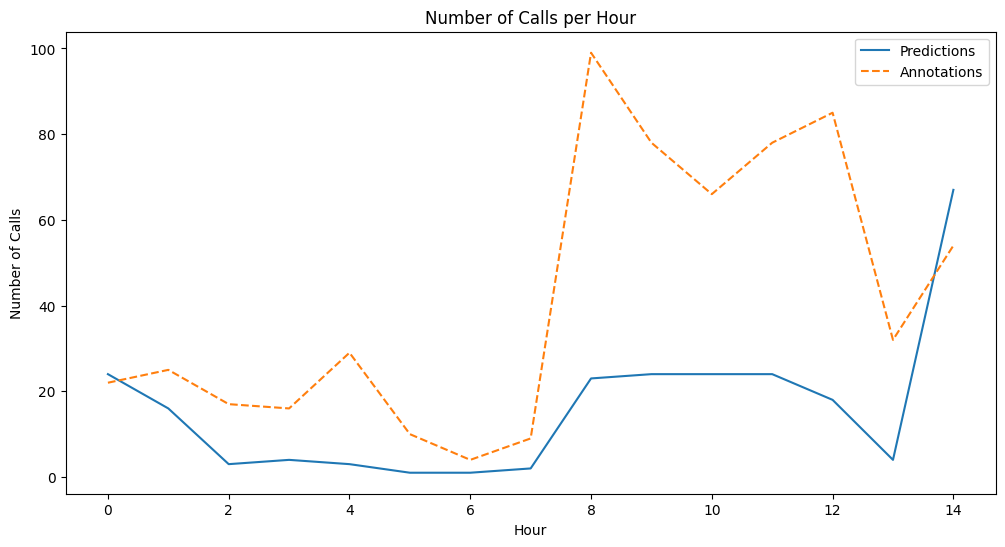

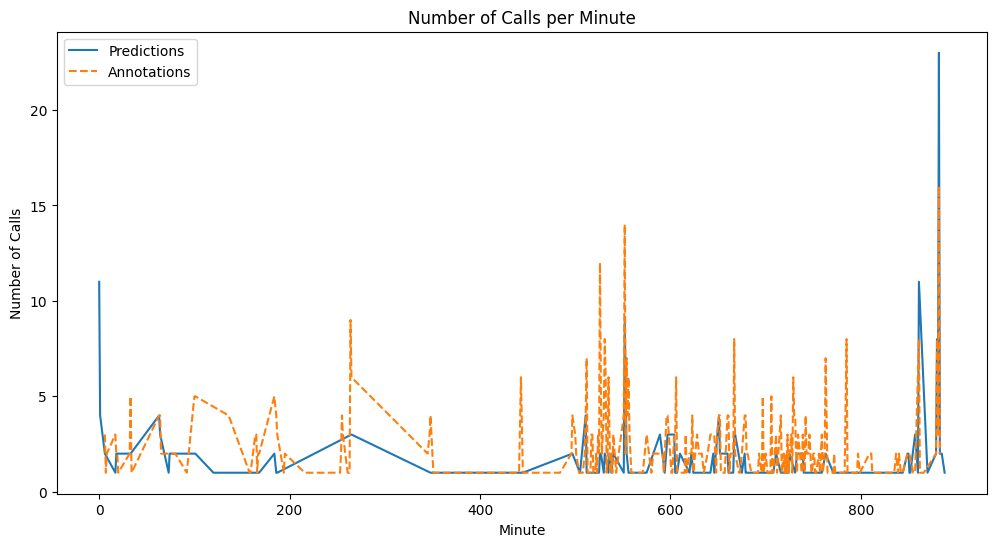

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to calculate the number of calls per time unit with continuous time
def calculate_calls_per_time_unit_continuous(predictions_df, threshold=0.5):
    # Filter predictions based on the threshold
    predictions_df['predicted_label'] = (predictions_df['1'] >= threshold).astype(int)
    # Initialize the offset
    time_offset = 0
    # List to store adjusted predictions
    adjusted_predictions = []
    # Dictionary to store recording durations
    recording_durations = {}
    # Process each recording file
    for recording_filename in predictions_df['recording_filename'].unique():
        recording_predictions = predictions_df[predictions_df['recording_filename'] == recording_filename].copy()
        
        # Adjust the time segments by adding the offset
        recording_predictions['adjusted_time_segment'] = recording_predictions['time_segment'] + time_offset
        
        # Update the offset for the next recording
        max_time_segment = recording_predictions['time_segment'].max()
        duration = max_time_segment + 0.2
        recording_durations[recording_filename] = duration
        time_offset += duration  # Use the total duration
        
        adjusted_predictions.append(recording_predictions)
    
    # Combine all adjusted predictions
    adjusted_predictions_df = pd.concat(adjusted_predictions, ignore_index=True)
    
    # Convert adjusted_time_segment to datetime format
    adjusted_predictions_df['datetime'] = pd.to_datetime(adjusted_predictions_df['adjusted_time_segment'], unit='s')
    
    # Calculate the number of calls per hour
    adjusted_predictions_df['hour'] = (adjusted_predictions_df['adjusted_time_segment'] // 3600).astype(int)
    calls_per_hour = adjusted_predictions_df[adjusted_predictions_df['predicted_label'] == 1].groupby('hour').size().reset_index(name='calls_per_hour')
    
    # Calculate the number of calls per minute
    adjusted_predictions_df['minute'] = (adjusted_predictions_df['adjusted_time_segment'] // 60).astype(int)
    calls_per_minute = adjusted_predictions_df[adjusted_predictions_df['predicted_label'] == 1].groupby('minute').size().reset_index(name='calls_per_minute')
    
    return calls_per_hour, calls_per_minute, recording_durations

# Calculate the number of calls per hour and per minute with continuous time
calls_per_hour, calls_per_minute, recording_durations = calculate_calls_per_time_unit_continuous(predictions_df, threshold=0.5)
# Function to calculate the number of calls per time unit with continuous time for annotations
def calculate_calls_per_time_unit_annotations(annotations_df, recording_durations):
    # Initialize the offset
    time_offset = 0
    
    # List to store adjusted annotations
    adjusted_annotations = []
    
    # Process each recording file
    for recording_filename in annotations_df['recording_filename'].unique():
        recording_annotations = annotations_df[annotations_df['recording_filename'] == recording_filename].copy()
        
        # Adjust the begin and end times by adding the offset
        recording_annotations['adjusted_begin_time'] = recording_annotations['Begin Time (s)'] + time_offset
        recording_annotations['adjusted_end_time'] = recording_annotations['End Time (s)'] + time_offset
        
        # Update the offset for the next recording
        # max_end_time = recording_annotations['End Time (s)'].max()
        duration = recording_durations.get(recording_filename) #, recording_annotations['End Time (s)'].max())
        time_offset += duration
        
        adjusted_annotations.append(recording_annotations)
    
    # Combine all adjusted annotations
    adjusted_annotations_df = pd.concat(adjusted_annotations, ignore_index=True)
    
    # Convert adjusted_begin_time to datetime format
    adjusted_annotations_df['datetime'] = pd.to_datetime(adjusted_annotations_df['adjusted_begin_time'], unit='s')
    
    # Calculate the number of calls per hour
    adjusted_annotations_df['hour'] = (adjusted_annotations_df['adjusted_begin_time'] // 3600).astype(int)
    calls_per_hour = adjusted_annotations_df.groupby('hour').size().reset_index(name='calls_per_hour')
    
    # Calculate the number of calls per minute
    adjusted_annotations_df['minute'] = (adjusted_annotations_df['adjusted_begin_time'] // 60).astype(int)
    calls_per_minute = adjusted_annotations_df.groupby('minute').size().reset_index(name='calls_per_minute')
    
    return calls_per_hour, calls_per_minute

# Calculate the number of calls per hour and per minute with continuous time for annotations
calls_per_hour_annotations, calls_per_minute_annotations = calculate_calls_per_time_unit_annotations(annotations_df, recording_durations)

# Plot the number of calls per hour
plt.figure(figsize=(12, 6))
plt.plot(calls_per_hour['hour'], calls_per_hour['calls_per_hour'], label='Predictions')
plt.plot(calls_per_hour_annotations['hour'], calls_per_hour_annotations['calls_per_hour'], label='Annotations', linestyle='--')
plt.xlabel('Hour')
plt.ylabel('Number of Calls')
plt.title('Number of Calls per Hour')
plt.legend()
plt.show()

# Plot the number of calls per minute
plt.figure(figsize=(12, 6))
plt.plot(calls_per_minute['minute'], calls_per_minute['calls_per_minute'], label='Predictions')
plt.plot(calls_per_minute_annotations['minute'], calls_per_minute_annotations['calls_per_minute'], label='Annotations', linestyle='--')
plt.xlabel('Minute')
plt.ylabel('Number of Calls')
plt.title('Number of Calls per Minute')
plt.legend()
plt.show()
# # Plot the number of calls per hour
# plt.figure(figsize=(12, 6))
# plt.plot(calls_per_hour['hour'], calls_per_hour['calls_per_hour'])
# plt.xlabel('Hour')
# plt.ylabel('Number of Calls')
# plt.title('Number of Calls per Hour')
# plt.show()

# # Plot the number of calls per minute
# plt.figure(figsize=(12, 6))
# plt.plot(calls_per_minute['minute'], calls_per_minute['calls_per_minute'])
# plt.xlabel('Minute')
# plt.ylabel('Number of Calls')
# plt.title('Number of Calls per Minute')
# plt.show()
